**Twiss of  sb_pdr w he_pdr knobs worked fine for twiss4d, gave dx beating in twiss6d (note: sb wigglers have different dx: 086_)**\
**->Match sb_pdr connections: ds and mds. Straights and arcs same knobs as he_pdr**

In [1]:
#%matplotlib inline
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xplt


/home/panos/miniforge3/envs/xsuite_sb_new/lib/python3.11/site-packages/xplt/hooks.py:31: RuntimeWarning: Failed to register formatters with pint: No module named 'pint'
  warnings.warn(f"Failed to register formatters with pint: {e}", RuntimeWarning)


In [2]:
# Load lattices
import xtrack as xt
env = xt.Environment()
env.call("00_lattice.py")

pdr = env['pdr']

Slicing line:   0%|          | 0/512 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/1584 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/2988 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/926 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/375 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/1628 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/375 [00:00<?, ?it/s]

**Match TME (arc cell)**

In [3]:
#targets
qxtme=5/17
qytme=3/17

#symmetric tme (markers)
tme_cell_s = env["tme_cell_s"] 

#knobs
k1tme=['kqfa', 'kqda']

#match
opt_tme = tme_cell_s.match(      # match one of the tme cells
    solve=False,
    method='4d',
    targets=xt.TargetSet(qx=qxtme, qy=qytme, tol=1e-5), #(qx=5./17, qy=3./17, tol=1e-5),
    vary=xt.VaryList(k1tme, step=1e-5),
)

#opt_tme.vary_status()
#opt_tme.target_status()

opt_tme.solve()      # get the knob values and save them

                                             
Optimize - start penalty: 0.04299                           
Matching: model call n. 11 penalty = 4.8036e-09              
Optimize - end penalty:  4.80365e-09                            


In [4]:
# Matched TME knobs
opt_tme.vary_status()
opt_tme.target_status()

# Extract knobs
strengths = opt_tme.get_knob_values()
xt.json.dump(strengths, '011_matching_knobs/tme_matched_k1s.json')

Vary status:                 
id state tag met name lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqfa None              2.47437 None              2.49239         1e-05             1
1  ON        OK  kqda None               -2.068 None             -2.06942         1e-05             1
Target status:               nalty = 4.8036e-09              
id state tag tol_met       residue   current_val    target_val description                             
0  ON    qx     True   2.56121e-10      0.294118      0.294118 'qx', val=0.294118, tol=1e-05, weight=10
1  ON    qy     True   -4.0639e-10      0.176471      0.176471 'qy', val=0.176471, tol=1e-05, weight=10


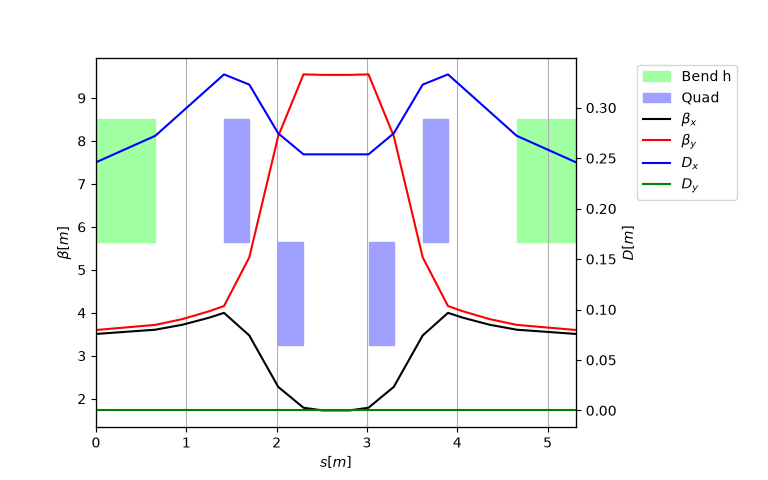

In [5]:
# Plot TME
opt_tme.plot()

**FODOw match:**

In [6]:
# Match
qxfd=0.2268
qyfd=0.229

opt_fodow = env["fodow_cell_s"].match(  ## fodow_cell_s_sb for splineboris wiggler fodow
    solve=False,
    method='4d',
    targets=xt.TargetSet(qx=qxfd, qy=qyfd, tol=1e-5),
    vary=xt.VaryList(['kqfw', 'kqdw'], step=1e-6),
)

In [7]:
opt_fodow.solve()
opt_fodow.vary_status()
opt_fodow.target_status()

Optimize - start penalty: 0.09165                         
Matching: model call n. 11 penalty = 1.9755e-07              
Optimize - end penalty:  1.97546e-07                            
Vary status:                 
id state tag met name lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqfw None              1.50694 None              1.55261         1e-06             1
1  ON        OK  kqdw None             -1.25966 None             -1.30164         1e-06             1
Target status:               nalty = 1.9755e-07              
id state tag tol_met       residue   current_val    target_val description                           
0  ON    qx     True   1.44567e-08        0.2268        0.2268 'qx', val=0.2268, tol=1e-05, weight=10
1  ON    qy     True   1.34628e-08         0.229         0.229 'qy', val=0.229, tol=1e-05, weight=10 


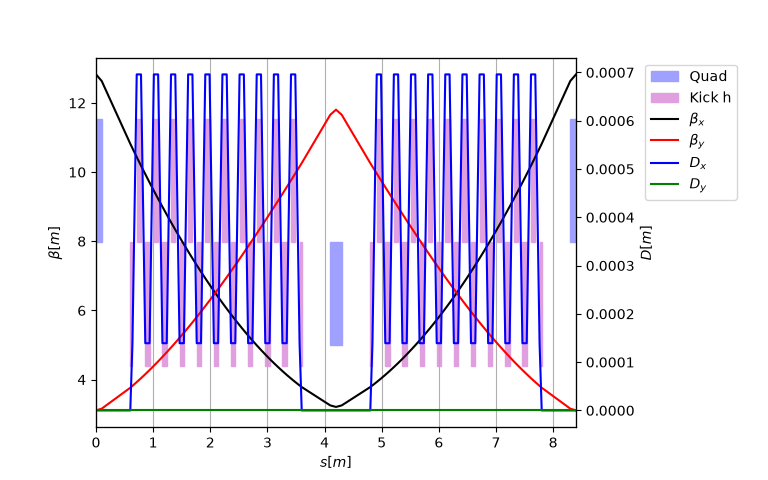

In [8]:
opt_fodow.plot()

In [9]:
# dump fodow k1s to json
tt_out = env.vars.get_table().rows[["kqfw", "kqdw"]]
ddd = tt_out.to_dict()
xt.json.dump(ddd, "011_matching_knobs/fodow_matched_k1s.json")

**Match dispsup and beta matching sections:**

In [10]:
# ============================================================
# Dispsup and beta match: arc -> straight 
# ============================================================

line_ds = env["ds_match"]

# Boundary optics
tw_arc1 = env["arc1"].twiss(method="4d", strengths=True)
tw_fodow = env["fodow_cell_s"].twiss(method="4d", strengths=True)

# Start boundary: arc optics
tw_dip_c = tw_arc1.rows["dip.tme_16.center"]

# End boundary: straight optics
tw_qfw_c = tw_fodow.rows["qfw.fodow_3.center"]  ## _sb for splineboris wiggler fodow

kqds = [
    "kqds11", "kqds12", "kqds13", "kqds14",
    "kqds15", "kqds16", "kqds17",
]

In [11]:
opt_ds = line_ds.match(
    solve=False,
    method="4d",
    start="dip.ds_1.1.center",
    end="qfw.fodow_10.center",
    init_at=xt.START,

    betx=tw_dip_c.betx[0],
    bety=tw_dip_c.bety[0],
    alfx=tw_dip_c.alfx[0],
    alfy=tw_dip_c.alfy[0],
    dx=tw_dip_c.dx[0],
    dpx=tw_dip_c.dpx[0],

    vary=xt.VaryList(kqds, step=1e-6),

    targets=[
        xt.TargetSet(
            at=xt.END,
            betx=tw_qfw_c.betx[0],
            bety=tw_qfw_c.bety[0],
            alfx=tw_qfw_c.alfx[0],
            alfy=tw_qfw_c.alfy[0],
            dx=tw_qfw_c.dx[0],
            dpx=tw_qfw_c.dpx[0],
            tol=1e-8,
        )
    ],
)

In [12]:
opt_ds.solve()
opt_ds.vary_status()
opt_ds.target_status()

                                             
Optimize - start penalty: 53.48                             
Matching: model call n. 81 penalty = 5.1220e-09              
Optimize - end penalty:  5.12201e-09                            
Vary status:                 
id state tag met name   lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqds11 None            -0.656765 None              -0.9513         1e-06             1
1  ON        OK  kqds12 None              2.94205 None              3.21539         1e-06             1
2  ON        OK  kqds13 None             -1.85068 None             -2.32272         1e-06             1
3  ON        OK  kqds14 None             -1.83951 None               -1.223         1e-06             1
4  ON        OK  kqds15 None              2.12671 None              2.07849         1e-06             1
5  ON        OK  kqds16 None           -0.0481602 None            -0.127425         1e-06             1
6  ON   

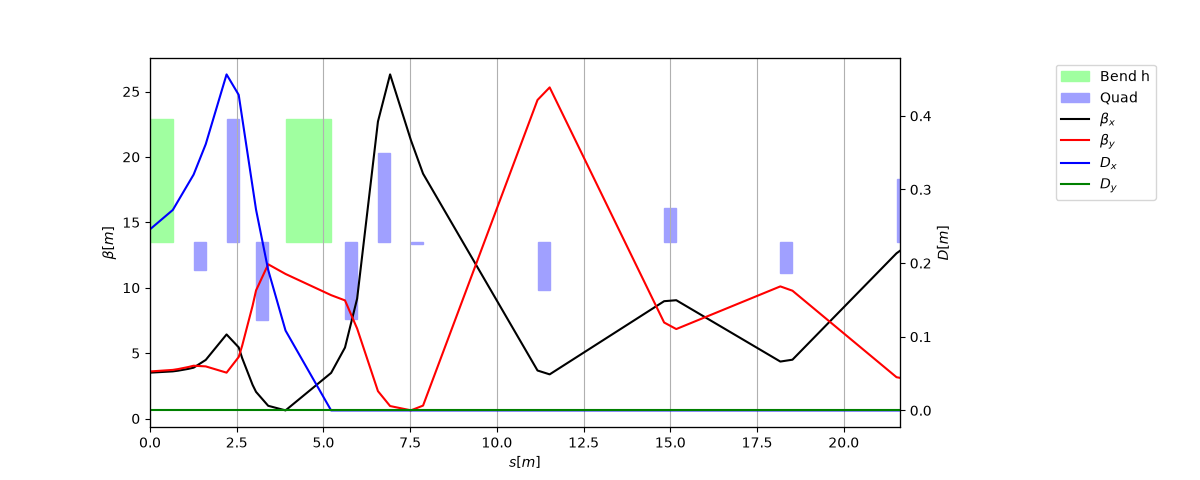

In [13]:
opt_ds.plot(lattice=True, figsize=(12,4.8))

In [14]:
# ============================================================
# MDS match: straight -> arc
# ============================================================

line_mds = env["mds_match"]

# Start
tw_fodow = env["fodow_cell_s"].twiss(method="4d", strengths=True)
tw_arc1 = env["arc1"].twiss(method="4d", strengths=True)

# End
tw_qfw_c = tw_fodow.rows["qfw.fodow_3.center"]
tw_dip_c = tw_arc1.rows["dip.tme_1.center"]

kqmds = [
    "kqds21", "kqds22", "kqds23", "kqds24",
    "kqds25", "kqds26", "kqds27",
    "kqds18", "kqds19",
]

In [15]:
opt_mds = line_mds.match(
    solve=False,
    method="4d",
    start="qfw.mds_1.1.center",
    end="dip.tme_1.center",
    init_at=xt.START,

    betx=tw_qfw_c.betx[0],
    bety=tw_qfw_c.bety[0],
    alfx=tw_qfw_c.alfx[0],
    alfy=tw_qfw_c.alfy[0],
    dx=tw_qfw_c.dx[0],
    dpx=tw_qfw_c.dpx[0],

    vary=xt.VaryList(kqmds, step=1e-6),

    targets=[
        xt.TargetSet(
            at=xt.END,
            betx=tw_dip_c.betx[0],
            bety=tw_dip_c.bety[0],
            alfx=tw_dip_c.alfx[0],
            alfy=tw_dip_c.alfy[0],
            dx=tw_dip_c.dx[0],
            dpx=tw_dip_c.dpx[0],
            tol=1e-8,
        )
    ],
)

In [16]:
opt_mds.solve()
opt_mds.vary_status()
opt_mds.target_status()

                                             
Optimize - start penalty: 0.5113                            
Matching: model call n. 49 penalty = 1.0397e-09              
Optimize - end penalty:  1.03974e-09                            
Vary status:                 
id state tag met name   lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqds21 None              2.18195 None              2.19352         1e-06             1
1  ON        OK  kqds22 None             -3.19539 None             -3.19312         1e-06             1
2  ON        OK  kqds23 None              2.94233 None              2.95241         1e-06             1
3  ON        OK  kqds24 None             -1.47506 None             -1.51828         1e-06             1
4  ON        OK  kqds25 None             0.453607 None             0.501438         1e-06             1
5  ON        OK  kqds26 None              1.32982 None              1.32368         1e-06             1
6  ON   

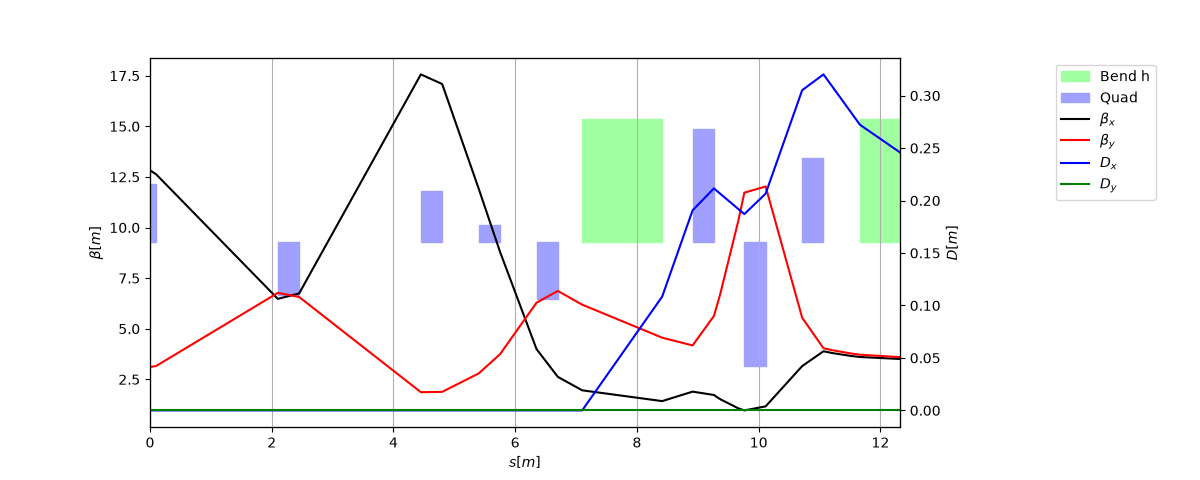

In [17]:
opt_mds.plot(lattice=True, figsize=(12,4.8))

**Get knobs**

In [18]:
# Extract ds knobs
tt_vars=env['ds_1'].vars.get_table()
tt_out=tt_vars.rows[kqds]
ds_k1s = tt_out.to_pandas()

# Save .csv
#ds_k1s.to_csv("ds_k1s.csv", index=True)

# Display
ds_k1s

,name,value,expr
0,kqds11,-0.656765,None
1,kqds12,2.942050,None
2,kqds13,-1.850679,None
3,kqds14,-1.839512,None
4,kqds15,2.126711,None
5,kqds16,-0.048160,None
6,kqds17,-1.135185,None


In [19]:
# Dump ds k1s to json
ddd = tt_out.to_dict()                    
xt.json.dump(ddd, '011_matching_knobs/ds_matched_k1s.json')

In [20]:
# Extract mds knobs
tt_vars=env['mds_1'].vars.get_table()
tt_out=tt_vars.rows[kqmds]
mds_k1s = tt_out.to_pandas()

# Save .csv
#mds_k1s.to_csv("mds_k1s.csv", index=True)

# Display
mds_k1s

,name,value,expr
0,kqds21,2.181949,None
1,kqds22,-3.195394,None
2,kqds23,2.942331,None
3,kqds24,-1.475061,None
4,kqds25,0.453607,None
5,kqds26,1.329817,None
6,kqds27,-1.352770,None
7,kqds18,0.817494,None
8,kqds19,-0.720294,None


In [21]:
# Dump mds k1s to json
ddd = tt_out.to_dict()                    
xt.json.dump(ddd, '011_matching_knobs/mds_matched_k1s.json')

**Now match k2s for pdr to have 0 chroma:**

In [22]:
ks=['ksx1','ksy1']

In [23]:
env.vars.update({
    'ksx1': 0.0,
    'ksy1': 0.0,
})
                 

In [24]:
opt_pdr = pdr.match(
    method='4d',
    name='pdr',
    solve=False,
    vary=[
        xt.VaryList(ks, step=1e-6, tag='sext'),
    ],
    targets = [
        xt.TargetSet(dqx=0, dqy=0, tol=1e-6, tag='linear chroma'),
    ])

In [25]:
opt_pdr.solve()
opt_pdr.vary_status()
opt_pdr.target_status()

                                             
Optimize [pdr] - start penalty: 25.98                         
Matching: model call n. 41 penalty = 3.4333e-07              
Optimize [pdr] - end penalty:  3.43334e-07                            
Vary status:                 
id state tag  met name lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON    sext OK  ksx1 None              14.3234 None                    0         1e-06             1
1  ON    sext OK  ksy1 None             -24.8247 None                    0         1e-06             1
Target status:               nalty = 3.4333e-07              
id state tag           tol_met       residue   current_val target_val description                      
0  ON    linear chroma    True  -3.43334e-07  -3.43334e-07          0 'dqx', val=0, tol=1e-06, weight=1
1  ON    linear chroma    True   1.42109e-10   1.42109e-10          0 'dqy', val=0, tol=1e-06, weight=1


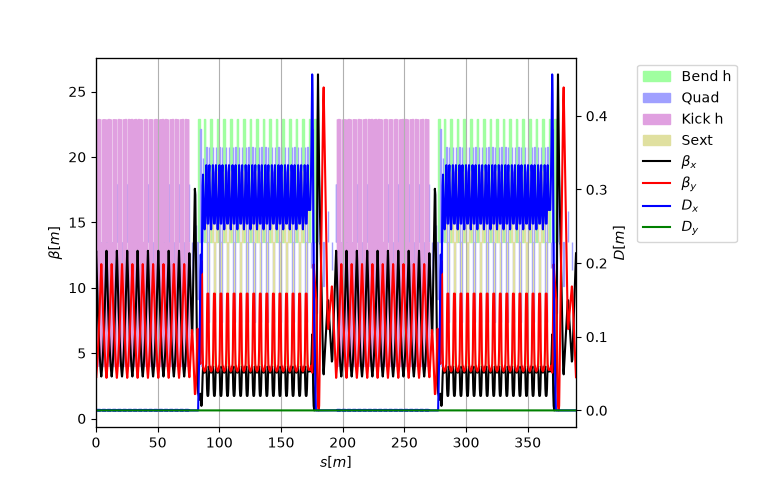

In [26]:
opt_pdr.plot()

In [27]:
# Extract k2s:
tt_vars=env['pdr'].vars.get_table()
tt_out=tt_vars.rows[ks]
pdr_k2s = tt_out.to_pandas()

# Save .csv
#pdr_k2s.to_csv("pdr_k2s.csv", index=True)

# Display
pdr_k2s

,name,value,expr
0,ksx1,14.323393,None
1,ksy1,-24.824696,None


In [28]:
# Dump pdr k2s to json
ddd = tt_out.to_dict()                    
xt.json.dump(ddd, '011_matching_knobs/pdr_k2s.json')